In [1]:
from pathlib import Path
import yaml
import cv2
import random
import matplotlib.pyplot as plt

DATASET = Path(r"D:\SIH26031\OnionModel\datasets\onion_segmentation")
DATA_YAML = DATASET / "data.yaml"
MODEL_PATH = Path(r"D:\SIH26031\OnionModel\yolo11n-seg.pt")
RUNS_DIR = Path(r"D:\SIH26031\OnionModel\results")

print("Dataset:", DATASET)
print("data.yaml:", DATA_YAML)
print("Model:", MODEL_PATH)
print("Dataset exists:", DATASET.exists())
print("data.yaml exists:", DATA_YAML.exists())
print("Model exists:", MODEL_PATH.exists())

Dataset: D:\SIH26031\OnionModel\datasets\onion_segmentation
data.yaml: D:\SIH26031\OnionModel\datasets\onion_segmentation\data.yaml
Model: D:\SIH26031\OnionModel\yolo11n-seg.pt
Dataset exists: True
data.yaml exists: True
Model exists: True


In [2]:
# Read and verify data.yaml
with open(DATA_YAML, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

print(yaml.safe_dump(cfg, sort_keys=False))

assert DATASET.exists(), f"Dataset folder not found: {DATASET}"
assert DATA_YAML.exists(), f"data.yaml not found: {DATA_YAML}"
assert "train" in cfg and "val" in cfg, "data.yaml must contain train and val"
assert "names" in cfg, "data.yaml must contain class names"

print("Classes:", cfg["names"])


path: D:/SIH26031/OnionModel/datasets/onion_D_K_merged
train: train/images
val: valid/images
test: test/images
nc: 2
names:
  0: coin
  1: onion

Classes: {0: 'coin', 1: 'onion'}


In [3]:
# Check dataset image/label counts and pairing
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "valid", "test"]:
    image_dir = DATASET / split / "images"
    label_dir = DATASET / split / "labels"

    if not image_dir.exists():
        print(f"{split}: image folder not found — skipping")
        continue

    images = [p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
    labels = list(label_dir.glob("*.txt")) if label_dir.exists() else []

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}
    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems

    print(f"{split:5} | images: {len(images):5} | labels: {len(labels):5} | missing labels: {len(missing_labels)} | missing images: {len(missing_images)}")

    if missing_labels:
        print("  Missing label examples:", sorted(missing_labels)[:10])
    if missing_images:
        print("  Missing image examples:", sorted(missing_images)[:10])

print("\nIf all missing counts are 0, image/label pairing is OK.")

train | images:    58 | labels:    58 | missing labels: 0 | missing images: 0
valid | images:    16 | labels:    16 | missing labels: 0 | missing images: 0
test  | images:    10 | labels:    10 | missing labels: 0 | missing images: 0

If all missing counts are 0, image/label pairing is OK.


In [4]:
# Check YOLO segmentation coordinates before training
def validate_label_file(label_path):
    errors = []
    for line_no, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), 1):
        parts = line.strip().split()
        if not parts:
            continue

        if len(parts) < 7:
            errors.append(f"line {line_no}: too few values for a polygon")
            continue

        try:
            int(parts[0])
            coords = [float(v) for v in parts[1:]]
        except ValueError:
            errors.append(f"line {line_no}: non-numeric value")
            continue

        if len(coords) % 2 != 0:
            errors.append(f"line {line_no}: odd number of coordinates")
        if any(v < 0 or v > 1 for v in coords):
            errors.append(f"line {line_no}: coordinate outside 0..1")
    return errors

bad = []
for split in ["train", "valid", "test"]:
    label_dir = DATASET / split / "labels"
    if not label_dir.exists():
        continue
    for label in label_dir.glob("*.txt"):
        errors = validate_label_file(label)
        if errors:
            bad.append((split, label.name, errors))

print("Invalid label files:", len(bad))
for item in bad[:20]:
    print(item)

assert not bad, "Fix invalid YOLO labels before training."
print("All YOLO segmentation labels pass coordinate validation.")

Invalid label files: 0
All YOLO segmentation labels pass coordinate validation.


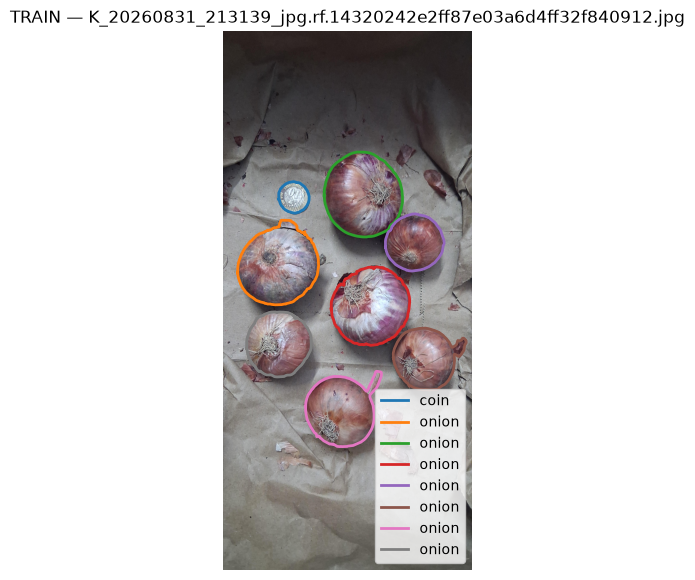

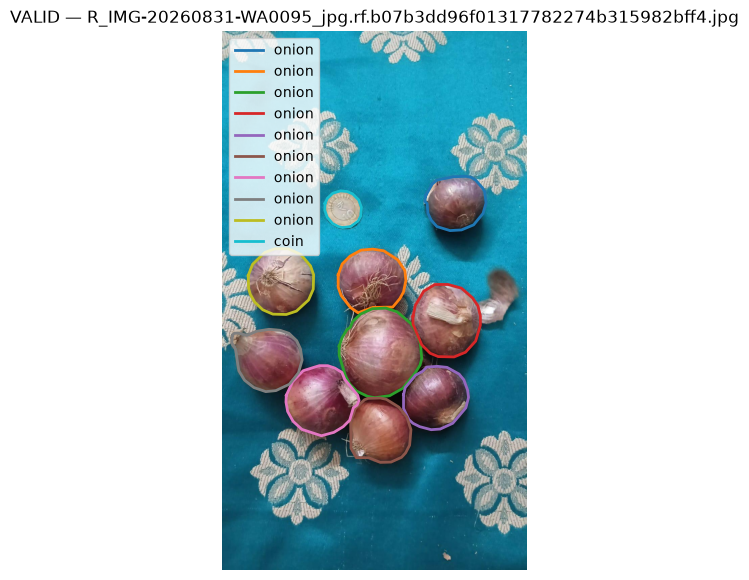

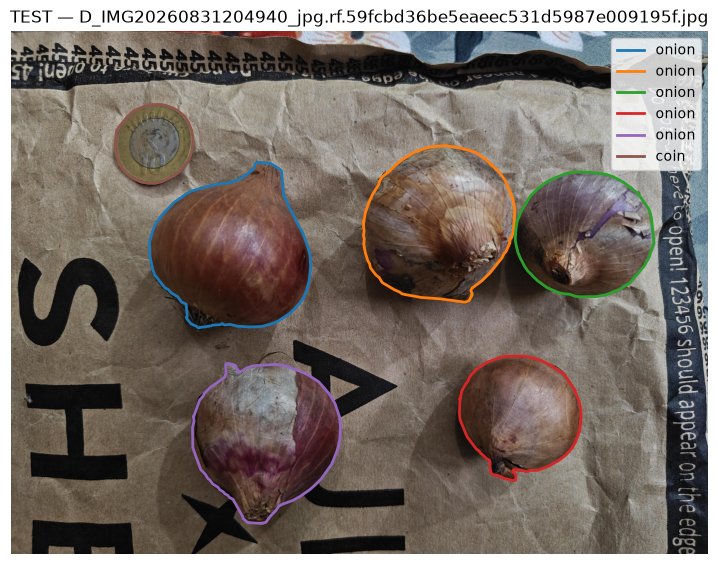

In [5]:
# Visual sanity check — one random image from each available split
class_names = cfg["names"]
if isinstance(class_names, dict):
    class_names = [class_names[k] for k in sorted(class_names, key=lambda x: int(x))]

for split in ["train", "valid", "test"]:
    image_dir = DATASET / split / "images"
    label_dir = DATASET / split / "labels"
    if not image_dir.exists():
        continue

    images = [p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
    if not images:
        continue

    image_path = random.choice(images)
    label_path = label_dir / f"{image_path.stem}.txt"
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    plt.figure(figsize=(9, 7))
    plt.imshow(image)

    if label_path.exists():
        for line in label_path.read_text(encoding="utf-8").splitlines():
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            class_id = int(parts[0])
            coords = [float(v) for v in parts[1:]]
            xs = [coords[i] * w for i in range(0, len(coords), 2)]
            ys = [coords[i] * h for i in range(1, len(coords), 2)]
            name = class_names[class_id] if class_id < len(class_names) else str(class_id)
            plt.plot(xs + [xs[0]], ys + [ys[0]], linewidth=2, label=name)

    plt.title(f"{split.upper()} — {image_path.name}")
    plt.axis("off")
    plt.legend()
    plt.show()

In [6]:
# Check GPU / PyTorch
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    DEVICE = 0
else:
    print("WARNING: CUDA is not available. Training will use CPU and may be much slower.")
    DEVICE = "cpu"

PyTorch: 2.13.0+cu126
CUDA available: True
CUDA version: 12.6
GPU: NVIDIA GeForce RTX 2050


In [8]:
# Train YOLO11 segmentation
from ultralytics import YOLO

RUNS_DIR.mkdir(parents=True, exist_ok=True)

model = YOLO(str(MODEL_PATH))

results = model.train(
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=4,
    patience=20,
    device=DEVICE,
    workers=4,
    project=str(RUNS_DIR),
    name="onion_segmentation_final",
    exist_ok=True,
    plots=True,
    save=True,
    cache=False
)

print("Training finished.")

Ultralytics 8.4.138  Python-3.14.6 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\SIH26031\OnionModel\datasets\onion_segmentation\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=D:\SIH26031\OnionModel\yolo11n-seg.pt, momentum=0.93

In [9]:
# Validate the trained model on the validation set
best_model_path = RUNS_DIR / "onion_segmentation_final" / "weights" / "best.pt"
print("Best model:", best_model_path)
print("Exists:", best_model_path.exists())

best_model = YOLO(str(best_model_path))
            
metrics = best_model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=640,
    batch=4,
    device=DEVICE,
    plots=True
)

print("Validation complete.")

Best model: D:\SIH26031\OnionModel\results\onion_segmentation_final\weights\best.pt
Exists: True
Ultralytics 8.4.138  Python-3.14.6 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,958 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2218.91259.9 MB/s, size: 1517.5 KB)
val: Scanning D:\SIH26031\OnionModel\datasets\onion_segmentation\valid\labels.cache... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16 6.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2it/s 3.2s0.5ss
                   all         16        161       0.99      0.993      0.994      0.916       0.99      0.993      0.994      0.889
                  coin         16         16      0.989          1      0.995      0.913      0.989          1      0.995      0.854
                 onion         16 

In [10]:
# Final test-set evaluation
test_metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=4,
    device=DEVICE,
    plots=True
)

print("Test evaluation complete.")

Ultralytics 8.4.138  Python-3.14.6 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 862.9359.8 MB/s, size: 1556.6 KB)
val: Scanning D:\SIH26031\OnionModel\datasets\onion_segmentation\test\labels... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 1.0Kit/s 0.0s
val: New cache created: D:\SIH26031\OnionModel\datasets\onion_segmentation\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.6s0.5ss
                   all         10        103      0.997          1      0.995       0.92      0.997          1      0.995      0.873
                  coin         10         10      0.996          1      0.995      0.913      0.996          1      0.995      0.831
                 onion         10         93      0.999          1      0.995      0.927      0.999          1      0.995      0.915
S

In [11]:
# Run predictions on a few test images
test_images = DATASET / "test" / "images"
sample_images = [p for p in test_images.iterdir() if p.suffix.lower() in IMAGE_EXTS]
sample_images = random.sample(sample_images, min(5, len(sample_images)))

prediction_dir = RUNS_DIR / "onion_segmentation_final" / "predictions"
prediction_dir.mkdir(parents=True, exist_ok=True)

predictions = best_model.predict(
    source=[str(p) for p in sample_images],
    imgsz=640,
    conf=0.25,
    device=DEVICE,
    save=True,
    project=str(prediction_dir),
    name="test_samples",
    exist_ok=True,
    show=False
)

print("Prediction check complete.")
print("Prediction output:", prediction_dir / "test_samples")


0: 640x640 1 coin, 9 onions, 9.0ms
1: 640x640 1 coin, 5 onions, 9.0ms
2: 640x640 1 coin, 7 onions, 9.0ms
3: 640x640 1 coin, 10 onions, 9.0ms
4: 640x640 1 coin, 26 onions, 9.0ms
Speed: 2.4ms preprocess, 9.0ms inference, 6.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\SIH26031\OnionModel\results\onion_segmentation_final\predictions\test_samples
Prediction check complete.
Prediction output: D:\SIH26031\OnionModel\results\onion_segmentation_final\predictions\test_samples
